In [1]:
import os
import glob
import numpy as np

# Text segmentation using Hidden Markov Models

## Automatic segmentation of mails

This Lab aims to build an email segmentation tool, dedicated to separate the email header from its
body. It is proposed to perform this task by learning a HMM $(A, B, \pi)$ with two states in $\mathcal{S} = \{1, 2\}$, one (state $1$) for the header, the other (state $2$) for the body.

#### Question one:

**What is the value of the $\pi$ vector of initial probabilities ?**

Knowing that each mail contains exactly one header and one body, each mail follows once the transition from $1$ to $2$. The transition matrix $(A(i, j) = P (j|i))_{i,j \in \mathcal{S}}$ estimated on a labeled small corpus has thus the following form :


$$A = \begin{pmatrix} 
0.999218078035812 & 0.000781921964187974 \\ 
0 & 1 
\end{pmatrix}$$

---

**Answer**:
The vector of initial probabilities is $\pi = (1, 0)^\top$.

In [2]:
# Inputs to the Viterbi function
# Create states id, the vector pi, and the matrix A as numpy arrays
states = np.array([1, 2])
start_prob = np.array([1, 0])
trans = np.array([[0.999218078035812, 0.000781921964187974], [0, 1]])

#### Question two:

- **What is the probability to move from state 1 to state 2 ?**
- **What is the probability to remain in state 2 ?**
- **What is the lower/higher probability ? Try to explain *why*.**

---

**Answer**:
- The probability to move from state 1 to state 2 is given by $A_{1, 2} \approx 0.00078\%$.
- The probability to remain in state 2 is given by $A_{2, 2} = 100\%$.
- Since we are dealing with a transition from the header to the body of an email, there is no way to go back to the header after being on the body, so the second row of $A$ makes sense. The first row tells us that while in the header, it is much more likely for the next character to still be in header than to turn into the body.

A mail is represented by a sequence of characters $m = (c_1, ..., c_{l_m})$ with the characters belonging to a character set $c \in \mathcal{C}$. Let $N = |\mathcal{C}|$ be the number of possible different characters. Each part of the mail is characterized by a discrete probability distribution on the characters depending on the states, contained in the emission matrix $B$.

#### Question three:

**What is the size of $B$ ?**

---

**Answer**: $B$ is a $N \times 2$ matrix that represents the probability of observing character $c \in \mathcal{C}$ in state $s \in \{1, 2\}$.

### Coding/Decoding Mails

Emails are represented as ASCII character vectors.
In ```dat.zip```, ```mail.txt``` can be transformed into a vector of numbers (between $0$ and $255$), with one vector per line in a text.
Files of the form ```dat/*.dat``` contain the already encoded versions of the corresponding mails. The list
is in ```mail.lst```.
Use the command ```np.loadtxt``` to load the ```dat``` files

In [3]:
ROOT = os.path.abspath('.')
DATA_DIR = os.path.join(ROOT,'dat')

In [4]:
# Iterate through files and load the text 
def files_iter(data_dir, with_name=False):
    files = glob.glob('{}/*.dat'.format((data_dir)))
    if with_name:
        for f in files:
            # Get the filename 
            name = f.split('/')[-1].split('.')[0]
            # Return filename and associated text
            yield name, np.loadtxt(f, dtype=int)
    else:
        for f in files :
            yield np.loadtxt(f)

In [5]:
# And we get a generator that will allow us to iterate through the mails
mail_iter = files_iter(DATA_DIR, with_name=True)

### Distribution files

For the first part of the Lab, we work with the distributions that are provided in the ```P.dat``` file.
Each of the columns of this file contains the distribution of the probabilities of occurrence of each
character of the ASCII codes respectively in the **header** and in the **body**. These distributions were learned on a small corpus labeled with $10$ emails; there are obvious differences, especially in areas where ASCII codes correspond to alphabetic characters, as you can see by viewing these distributions.

In [6]:
PERL_DIR = os.path.join(ROOT,'PerlScriptAndModel')

In [7]:
# Writing a function to get the probability data
def get_emission_prob():
    return np.loadtxt('{}/P.dat'.format(PERL_DIR))

# Get the B matrix
emission_prob = get_emission_prob()

### Visualizing emission probabilities

Complete the following matplotlib code to visualize the emission probabilites. Check that the matrix is indeed normalized as two probability distributions over the characters, one for each state. 

In [8]:
import matplotlib.pyplot as plt

1.000000390922009 1.000000612724449


/Users/vicentin/.pyenv/versions/3.12.9/envs/telecom-paris/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 0 ( ) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/vicentin/.pyenv/versions/3.12.9/envs/telecom-paris/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 1 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/vicentin/.pyenv/versions/3.12.9/envs/telecom-paris/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/vicentin/.pyenv/versions/3.12.9/envs/telecom-paris/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/vicentin/.pyenv/versions/3.12.9/envs/telecom-paris/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: U

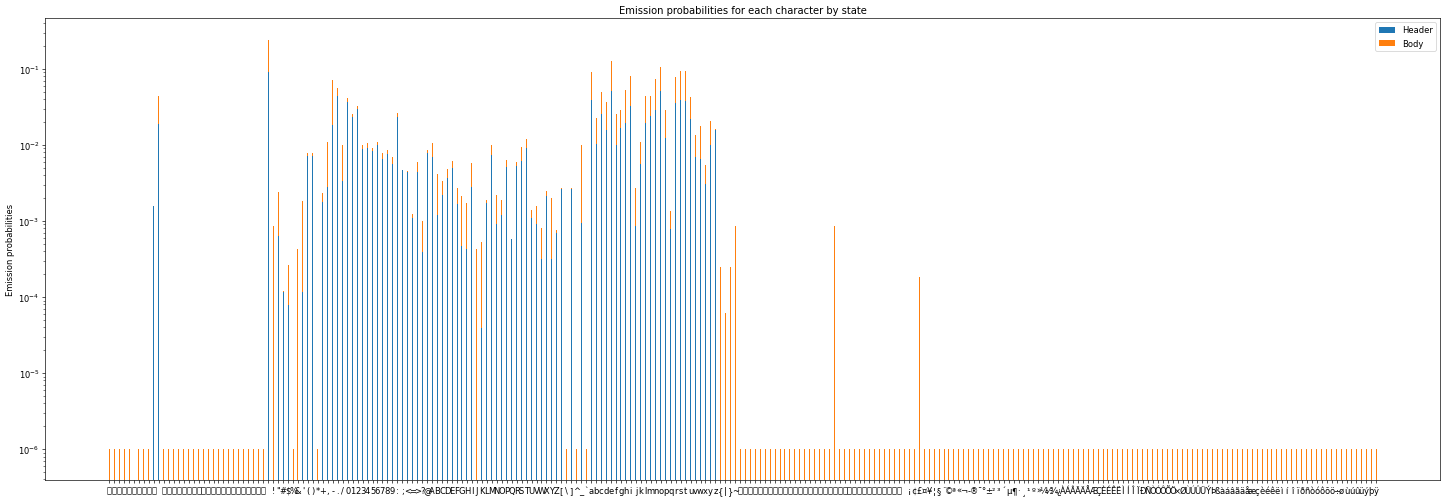

In [9]:
# Check that for each state we have a probability distribution over characters
print(np.sum(emission_prob[:, 0]), np.sum(emission_prob[:, 1]))

N = emission_prob.shape[0]
ind = np.arange(N)
width = 0.2

plt.figure(num=None, figsize=(30, 10), dpi=60, facecolor='w', edgecolor='k')
# Histogram, with values from emission probabilies for state 1
p1 = plt.bar(ind, emission_prob[:, 0], width)
# And state 2, displayed above the values for state 1 (argument "bottom")
p2 = plt.bar(ind, emission_prob[:, 1], width,
             bottom=emission_prob[:, 0])

plt.ylabel('Emission probabilities')
plt.title('Emission probabilities for each character by state')
plt.xticks(ind, [chr(i) for i in ind])
plt.yscale('log')
plt.legend((p1[0], p2[0]), ('Header', 'Body'))
plt.rc('axes', unicode_minus=False)
plt.show()

### Viterbi Algorithm

Complete the following function to implement the Viberti algorithm. Apply it to all the data and write the results in a specific ```res``` directory. The results are the **best paths** found by the Viterbi algorithm (in a vector of states, $1$ and $2$).

In [10]:
# Viterbi function
def viterbi(obs, states, start_prob, trans, emission_prob):
    """
        Viterbi Algorithm Implementation

        Keyword arguments:
            - obs: sequence of observation
            - states:list of states
            - start_prob:vector of the initial probabilities
            - trans: transition matrix
            - emission_prob: emission probability matrix
        Returns:
            - seq: sequence of state
    """

    # Avoid underflow: use the logarithm !
    # Avoid 0 in logarithm: use a small constant !
    small = 1e-12

    start_prob = np.log(start_prob + small)
    trans = np.log(trans + small)
    emission_prob = np.log(emission_prob + small)
    
    T = obs.shape[0] # Number of observations
    N = states.size # Number of model states
    
    # Initialisation
    logl = np.zeros((T, N))
    bcktr = np.zeros((T, N), dtype=int)
    
    # Viterbi
    
    # Forward loop:
    logl[0,:] =  start_prob + emission_prob[obs[0]]
    for t in range(1, T):
        states_matrix_probs = logl[t - 1][:, np.newaxis] + trans + emission_prob[obs[t]]
        
        logl[t, :] = np.max(states_matrix_probs, axis=0)
        bcktr[t, :] = np.argmax(states_matrix_probs, axis=0)
    # Backward loop
    path = [0] * T
    path[-1] = np.argmax(logl[-1, :]) + 1
    for i in range(T-1, 0, -1):
        path[i - 1] = bcktr[i - 1][path[i] - 1] + 1

    return path

In [11]:
# Creating a directory to put the result of the viterbi function
RES_DIR = './res'

if not os.path.exists(RES_DIR):
    os.mkdir(RES_DIR)
    
# Function that will write a viterbi path for a mail in a dedicated result file
def create_viterbi_path_file(mail_name, viterbi_path):
    with open('{}/{}_path.txt'.format(RES_DIR, mail_name), 'w') as f: 
        f.write(''.join([str(c) for c in viterbi_path]))   

In [12]:
# Using our generator, we get the mail names and data
for name_file, data in mail_iter:
    # Find out the viterbi path using viterbi
    viterbi_path = viterbi(data, states, start_prob, trans, emission_prob)
    # Put it in the result file
    create_viterbi_path_file(name_file, viterbi_path)

### Visualizing segmentation

Finally, the utility ```segment.pl``` allows to visualize a segmentation produced by your segmenter. It produces a string which contains the segmentation. It calls ```coder.pl``` that encodes the mail in ascii. To use it, use the ```exec_perl_script``` function which follows. 

In [13]:
# Writing a function to go into the directory and execute the perl script "segment.pl" on the mail in the given path
def exec_perl_script(mail, path):
    res = !cd {PERL_DIR}; perl segment.pl {mail} {path}
    return res

TOKEN_CUT = '========================== coupez ici =========================='

In [29]:
# Writing a function getting the original mail, the result of viterbi, and applying the segmentation script
# Then putting the result
def segment_mail(mail_name, data_dir, output_dir):
    # Get the full path of the mail
    mail = os.path.join(data_dir, mail_name + ".txt")
    # Get the full path of the result
    path = os.path.join(RES_DIR, mail_name + "_path.txt")
    path = os.path.abspath(path)
    
    # Execute the visualization script
    ret = exec_perl_script(mail, path)
    # Get the results
    formatted_mail_text = '\n'.join(ret[1:])
    # Go through the resulting text until the cutting line
    formatted_mail_text_split = formatted_mail_text.split(TOKEN_CUT)
    header = formatted_mail_text_split[0]
    # If this was not the last line, return the text cut in to parts: header and body
    body = []
    if len(formatted_mail_text_split) > 1:
        body = formatted_mail_text_split[1]
    # If not, it's just a header
    return header, body

#### Question four:

**Print the track and present and discuss the results obtained on ```mail11.txt``` to ```mail30.txt```**.

In [31]:
# Getting mails names
# Or just try it mail by mail manually
for name, data in files_iter(DATA_DIR, with_name=True):
    header, body = segment_mail(name, DATA_DIR, None)
    print(name, "============================\n")
    print("Header:\n", header)
    print("Body:\n", body)
# Call the function and look at the result of segmentation
...

mail21 ============================

Header:
 From timc@2ubh.com  Thu Aug 22 17:31:00 2002
Return-Path: <timc@2ubh.com>
Delivered-To: zzzz@localhost.netnoteinc.com
Received: from localhost (localhost [127.0.0.1])
	by phobos.labs.netnoteinc.com (Postfix) with ESMTP id A97BE43F99
	for <zzzz@localhost>; Thu, 22 Aug 2002 12:30:58 -0400 (EDT)
Received: from phobos [127.0.0.1]
	by localhost with IMAP (fetchmail-5.9.0)
	for zzzz@localhost (single-drop); Thu, 22 Aug 2002 17:30:58 +0100 (IST)
Received: from n17.grp.scd.yahoo.com (n17.grp.scd.yahoo.com
    [66.218.66.72]) by dogma.slashnull.org (8.11.6/8.11.6) with SMTP id
    g7MGOFZ14344 for <zzzz@spamassassin.taint.org>; Thu, 22 Aug 2002 17:24:16 +0100
X-Egroups-Return: sentto-2242572-52744-1030033454-zzzz=spamassassin.taint.org@returns.groups.yahoo.com
Received: from [66.218.67.201] by n17.grp.scd.yahoo.com with NNFMP;
    22 Aug 2002 16:24:16 -0000
X-Sender: timc@2ubh.com
X-Apparently-To: zzzzteana@yahoogroups.com
Received: (EGP: mail-8_1_0

Ellipsis

#### Question five:

**How would you model the problem if you had to segment the mails in more than two parts (for example : header, body, signature) ?**

**Answer**: We could add a third state for the signature.

#### Question six:

**How would you model the problem of separating the portions of mail included, knowing that they always start with the character ">" ?** 

**Answer**: If each portion of the mail starts with the same character and this character is not used elsewhere, no HMM would be needed.